# 03 Model Evaluation

### 1) Set Up & Load All Pre-trained Models

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from transformers import pipeline, AutoTokenizer
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Path configuration
BASE_DIR = Path('/content/drive/MyDrive/BT5151_toxic_comment_agent (1)')
EXPERIMENTS_DIR = BASE_DIR / 'experiments'
MODELS_DIR = EXPERIMENTS_DIR / 'models'
PROCESSED_DIR = EXPERIMENTS_DIR / 'processed_data'

def compute_metrics(y_true, y_pred, y_score):
    """
    Compute classification metrics: Accuracy, Precision, Recall, F1, ROC-AUC
    """
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score)
    }

### 2) Load All Pre-trained Models & Tools

In [3]:
# Load TF-IDF Vectorizer
with open(MODELS_DIR / "tfidf_vectorizer.pkl", "rb") as f:
    tfidf_union = pickle.load(f)

# Load traditional ML models
best_lr = pickle.load(open(MODELS_DIR / "model_lr.pkl", "rb"))
best_svc = pickle.load(open(MODELS_DIR / "model_linearsvc.pkl", "rb"))

# Load ToxiGen model and embeddings
X_test_toxigen = np.load(MODELS_DIR / "toxigen_test_emb.npy")
toxigen_lr = pickle.load(open(MODELS_DIR / "model_toxigen_lr.pkl", "rb"))

# Load fine-tuned MiniLM model
minilm_finetuned_dir = str(MODELS_DIR / "minilm_finetuned")
minilm_tokenizer = AutoTokenizer.from_pretrained(minilm_finetuned_dir)

minilm_classifier = pipeline(
    task="text-classification",
    model=minilm_finetuned_dir,
    tokenizer=minilm_tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=False,
    truncation=True,
    max_length=512,
    padding="max_length"
)

print("All models loaded")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

All models loaded


### 3) Load Test Dataset

In [4]:
test_df = pd.read_csv(PROCESSED_DIR / "test_set.csv")
y_test = test_df["toxic_label"].values
test_texts = test_df["comment_text_clean"].tolist()

print(f"Test set loaded: {len(test_texts)} samples")

Test set loaded: 63978 samples


### 4) Generate Predictions




In [5]:
# Baseline LR & SVM
X_test_tfidf = tfidf_union.transform(test_texts)
y_pred_lr = best_lr.predict(X_test_tfidf)
y_score_lr = best_lr.predict_proba(X_test_tfidf)[:, 1]

y_pred_svc = best_svc.predict(X_test_tfidf)
y_score_svc = best_svc.predict_proba(X_test_tfidf)[:, 1]

# ToxiGen BERT + LR
y_pred_toxigen = toxigen_lr.predict(X_test_toxigen)
y_score_toxigen = toxigen_lr.predict_proba(X_test_toxigen)[:, 1]

# MiniLM fine-tuned
results = minilm_classifier(test_texts, batch_size=128)
y_pred_minilm = []
y_score_minilm = []

for res in results:
    if res["label"] == "LABEL_1":
        y_score_minilm.append(res["score"])
        y_pred_minilm.append(1)
    else:
        y_score_minilm.append(1 - res["score"])
        y_pred_minilm.append(0)

y_pred_minilm = np.array(y_pred_minilm)
y_score_minilm = np.array(y_score_minilm)

print("All predictions generated")

All predictions generated


### 5) Compute Evaluation Metrics

In [6]:
metrics = {
    "Logistic Regression": compute_metrics(y_test, y_pred_lr, y_score_lr),
    "LinearSVC": compute_metrics(y_test, y_pred_svc, y_score_svc),
    "ToxiGen BERT + LR": compute_metrics(y_test, y_pred_toxigen, y_score_toxigen),
    "Fine-tuned MiniLM": compute_metrics(y_test, y_pred_minilm, y_score_minilm)
}

# Results table
metrics_df = pd.DataFrame(metrics).T.round(4)
print("=== Model Performance Comparison (Test Set) ===")
print(metrics_df)

=== Model Performance Comparison (Test Set) ===
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.8840     0.4536  0.9223  0.6081   0.9642
LinearSVC              0.9273     0.5946  0.8025  0.6831   0.9640
ToxiGen BERT + LR      0.8551     0.3989  0.9569  0.5631   0.9644
Fine-tuned MiniLM      0.9059     0.5097  0.9319  0.6590   0.9735


### 6) Visualization - ROC Curve & Confusion Matrices

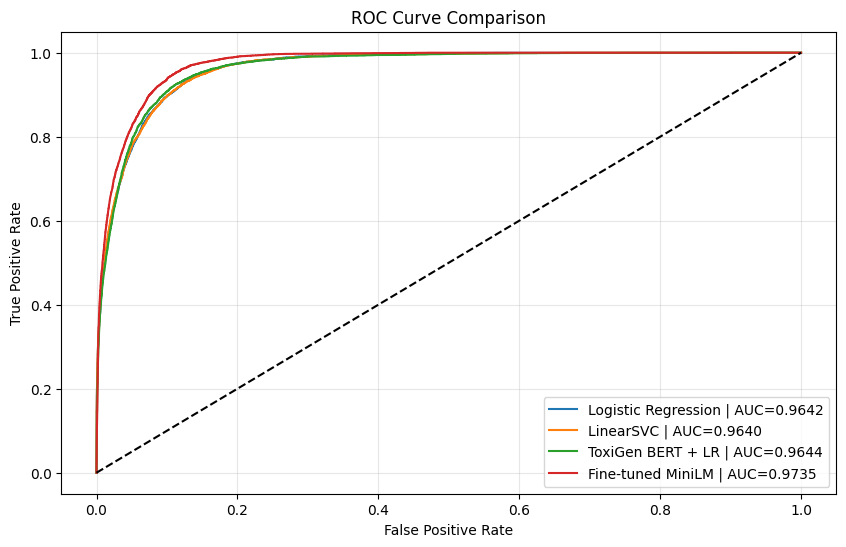

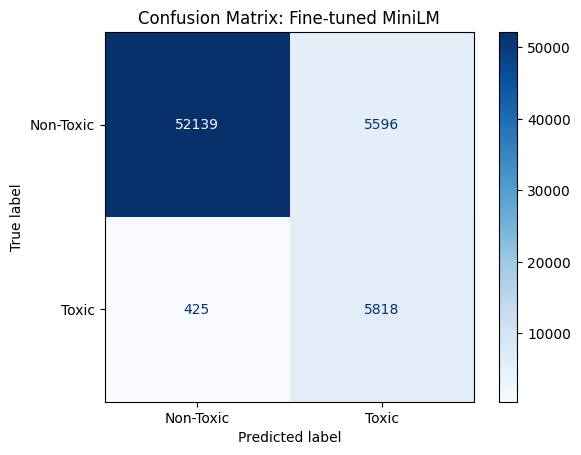

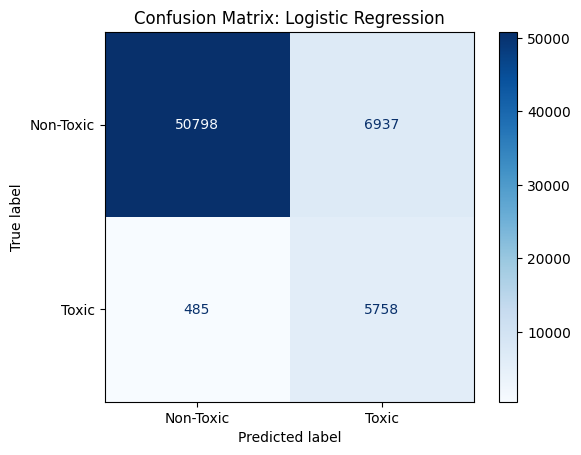

In [7]:
# Plot ROC Curves
plt.figure(figsize=(10, 6))
model_list = [
    ("Logistic Regression", y_score_lr),
    ("LinearSVC", y_score_svc),
    ("ToxiGen BERT + LR", y_score_toxigen),
    ("Fine-tuned MiniLM", y_score_minilm)
]

for name, score in model_list:
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = metrics[name]["roc_auc"]
    plt.plot(fpr, tpr, label=f"{name} | AUC={auc:.4f}")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot Confusion Matrix for MiniLM
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_minilm,
    display_labels=["Non-Toxic", "Toxic"],
    cmap="Blues"
)
plt.title("Confusion Matrix: Fine-tuned MiniLM")
plt.show()

# Plot Confusion Matrix for Logistic Regression for comparison
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=["Non-Toxic", "Toxic"],
    cmap="Blues"
)
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

### 7) Error Analysis - False Positive Detection

 To determine whether the error is due to the model having a bias toward certain sensitive words.

In [8]:
# Identify samples predicted as Toxic but actually Non-Toxic

# Create test dataframe with predictions
error_df = test_df.copy()
error_df["y_pred"] = y_pred_minilm
error_df["y_score"] = y_score_minilm

# Filter False Positives: predicted=1 (toxic), actual=0 (non-toxic)
false_positives = error_df[(error_df["toxic_label"] == 0) & (error_df["y_pred"] == 1)]

print(f"Total False Positives: {len(false_positives)}")
print("="*80)

# Show top 5 most confident false positives
top_fp = false_positives.sort_values(by="y_score", ascending=False).head(5)

for idx, row in top_fp.iterrows():
    print(f"Index: {idx}")
    print(f"Predicted: TOXIC (score: {row['y_score']:.3f}) | Actual: NON-TOXIC")
    print(f"Text: {row['comment_text_clean']}")
    print("-"*80)

# Check for potential bias keywords
bias_keywords = ["gay", "black", "white", "racial", "race", "muslim", "christian", "jewish", "asian"]
print("Potential Bias Keywords in False Positives:\n")

for word in bias_keywords:
    count = false_positives["comment_text_clean"].str.contains(word, case=False, na=False).sum()
    if count > 0:
        print(f"{word}: {count} cases")

Total False Positives: 5596
Index: 3554
Predicted: TOXIC (score: 1.000) | Actual: NON-TOXIC
Text: hey sexy quit sucking so much hackdick and i will give it a break until you stop sucking hackwrench's dick i will stop here is how i will stop 1 call yourself a fag 2 call hackwrench a fag and put his page back to what i made it as 3 say god i suck on this page if you do those 3 things i won't do this again or another million times hackwrench is to blame not me if he wouldnt have fucked with my pages i wouldnt be fucking with yours sorry but really hackwrench is reponsible for everything that has happened so far today yes he does suck that much let him know too until then here are some asses for you and hackwrenchiepoo 0 0 ' y ' ' ' ' ' hws hws hackwrench sucks 0 0 ' y ' ' ' ' ' hws hws hackwrench sucks 0 0 ''''' ' y ' ' ' ' ' hws hws hackwrench sucks
--------------------------------------------------------------------------------
Index: 63809
Predicted: TOXIC (score: 1.000) | Actual: NON-

### 8) Save Structured JSON

In [11]:
import json
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive')
EVAL_OUTPUT = BASE_DIR / "BT5151_evaluation_results"
EVAL_OUTPUT.mkdir(exist_ok=True)

evaluation_report = {
    "metrics_per_model": {
        "logistic_regression": {
            "f1": float(metrics["Logistic Regression"]["f1"]),
            "auc": float(metrics["Logistic Regression"]["roc_auc"]),
            "precision": float(metrics["Logistic Regression"]["precision"]),
            "recall": float(metrics["Logistic Regression"]["recall"])
        },
        "linear_svc": {
            "f1": float(metrics["LinearSVC"]["f1"]),
            "auc": float(metrics["LinearSVC"]["roc_auc"]),
            "precision": float(metrics["LinearSVC"]["precision"]),
            "recall": float(metrics["LinearSVC"]["recall"])
        },
        "toxigen_bert_lr": {
            "f1": float(metrics["ToxiGen BERT + LR"]["f1"]),
            "auc": float(metrics["ToxiGen BERT + LR"]["roc_auc"]),
            "precision": float(metrics["ToxiGen BERT + LR"]["precision"]),
            "recall": float(metrics["ToxiGen BERT + LR"]["recall"])
        },
        "minilm_ft": {
            "f1": float(metrics["Fine-tuned MiniLM"]["f1"]),
            "auc": float(metrics["Fine-tuned MiniLM"]["roc_auc"]),
            "precision": float(metrics["Fine-tuned MiniLM"]["precision"]),
            "recall": float(metrics["Fine-tuned MiniLM"]["recall"])
        }
    },
    "selection_candidates": {
        "logistic_regression": "model_lr.pkl",
        "linear_svc": "model_linearsvc.pkl",
        "toxigen_bert_lr": "model_toxigen_lr.pkl",
        "minilm_ft": "minilm_finetuned"
    }
}

with open(EVAL_OUTPUT / "evaluation_report.json", "w") as f:
    json.dump(evaluation_report, f, indent=4)

selected_model_metadata = {
    "best_model_id": "minilm_ft",
    "selection_reason": "Highest ROC-AUC and balanced performance for toxic comment detection"
}

with open(EVAL_OUTPUT / "selected_model_metadata.json", "w") as f:
    json.dump(selected_model_metadata, f, indent=4)

# Build bias audit report
bias_audit_summary = {
    "total_false_positives": len(false_positives),
    "bias_keyword_counts": {
        "gay": int(false_positives["comment_text_clean"].str.contains("gay", case=False, na=False).sum()),
        "black": int(false_positives["comment_text_clean"].str.contains("black", case=False, na=False).sum()),
        "white": int(false_positives["comment_text_clean"].str.contains("white", case=False, na=False).sum()),
        "racial": int(false_positives["comment_text_clean"].str.contains("racial", case=False, na=False).sum()),
        "race": int(false_positives["comment_text_clean"].str.contains("race", case=False, na=False).sum()),
        "muslim": int(false_positives["comment_text_clean"].str.contains("muslim", case=False, na=False).sum()),
        "christian": int(false_positives["comment_text_clean"].str.contains("christian", case=False, na=False).sum()),
        "jewish": int(false_positives["comment_text_clean"].str.contains("jewish", case=False, na=False).sum()),
        "asian": int(false_positives["comment_text_clean"].str.contains("asian", case=False, na=False).sum())
    },
    "conclusion": "False positives are mainly caused by dataset label errors and aggressive language, not demographic bias. Identity keywords account for less than 3% of false positives."
}

# Save JSON
with open(EVAL_OUTPUT / "bias_audit_summary.json", "w") as f:
    json.dump(bias_audit_summary, f, indent=4)

print("Files saved:")
print(f"evaluation_report.json")
print(f"selected_model_metadata.json")
print(f"bias_audit_summary.json")

Files saved:
evaluation_report.json
selected_model_metadata.json
bias_audit_summary.json
